In [2]:
import os
from dotenv import load_dotenv
import requests
import pandas as pd
import os
from dotenv import load_dotenv
import time
import duckdb
import matplotlib.pyplot as plt

We are not going to rerun this cell as it there are 21M rows and it took forever

In [37]:
load_dotenv()
API_KEY = os.getenv('AVIATION_EDGE_KEY') # Store your key in a .env file
BASE_URL = "https://aviation-edge.com/v2/public/flightsHistory"

# List of Top 50 Busiest US Airports (IATA Codes)
# Based on 2024/2025 passenger enplanement ranks
US_TOP_50 = [
    "ATL", "DFW", "DEN", "ORD", "LAX", "JFK", "CLT", "LAS", "MCO", "MIA",
    "PHX", "SEA", "SFO", "EWR", "IAH", "BOS", "MSP", "FLL", "LGA", "PHL",
    "SLC", "DCA", "SAN", "BWI", "TPA", "MDW", "BNA", "IAD", "PDX", "HNL",
    "RSW", "STL", "AUS", "SJC", "MSY", "RDU", "SNA", "SMF", "HOU", "BUR",
    "ONT", "CLE", "MCI", "SJU", "PIT", "SAT", "CVG", "OGG", "PBI", "IND"
]

def fetch_airport_data(iata_code, date_from, date_to):
    params = {
        "key": API_KEY,
        "code": iata_code,
        "type": "departure",
        "date_from": date_from,
        "date_to": date_to
    }
    
    try:
        response = requests.get(BASE_URL, params=params)
        response.raise_for_status() # Raise error for bad status codes
        data = response.json()
        
        # If the API returns an error message in JSON instead of a list
        if isinstance(data, dict) and "error" in data:
            print(f"Error for {iata_code}: {data['error']}")
            return None
            
        return data
    except Exception as e:
        print(f"Failed to fetch {iata_code}: {e}")
        return None


all_flights = []
START_DATE = "2024-01-01"
END_DATE = "2026-01-01"

print(f"Starting data collection for {len(US_TOP_50)} airports...")

for code in US_TOP_50:
    print(f"Fetching {code}...")
    data = fetch_airport_data(code, START_DATE, END_DATE)
    
    if data:
        # Flatten the nested JSON structure (airline, departure, arrival info)
        df_temp = pd.json_normalize(data)
        # Add a column so we know which airport this belongs to
        df_temp['query_airport'] = code
        all_flights.append(df_temp)
    
    # to avoid rate limits
    time.sleep(5)

if all_flights:
    # Combine all dataframes into one
    final_df = pd.concat(all_flights, ignore_index=True)
    
    # Save to CSV
    output_file = "temp_flights.csv"
    final_df.to_csv(output_file, index=False)
    print(f"Success! Combined data saved to {output_file}")
    print(f"Total flights recorded: {len(final_df)}")
else:
    print("No data was collected.")



Starting data collection for 50 airports...
Fetching ATL...
Fetching DFW...
Fetching DEN...
Fetching ORD...


KeyboardInterrupt: 

In [3]:
def ingest_to_duckdb(csv_path, db_path):
    """Loads the CSV data into a DuckDB table."""
    print(f"Ingesting {csv_path} into DuckDB database: {db_path}")
    
    # Connect to the database (creates it if it doesn't exist)
    con = duckdb.connect(db_path)
    
    try:
        # read_csv_auto handles headers and type detection
        # comment='#' skips the metadata lines typical of ASOS reports
        con.execute(f"""
            CREATE OR REPLACE TABLE flights AS 
            SELECT * FROM read_csv_auto('{csv_path}', comment='#');
        """)
        
        count = con.execute("SELECT count(*) FROM flights").fetchone()[0]
        print(f"Success! Ingested {count:,} rows.")
    finally:
        con.close()


ingest_to_duckdb("temp_flights.csv", "flight_data.duckdb")

Ingesting temp_flights.csv into DuckDB database: flight_data.duckdb
Success! Ingested 20,928,599 rows.


In [4]:
top50 = [
    "ATL", "DFW", "DEN", "ORD", "LAX", "JFK", "CLT", "LAS", "MCO", "MIA",
    "PHX", "SEA", "SFO", "EWR", "IAH", "BOS", "MSP", "FLL", "LGA", "DTW",
    "PHL", "SLC", "BWI", "IAD", "SAN", "DCA", "MDW", "TPA", "HNL", "PDX",
    "BNA", "AUS", "STL", "DAL", "SJC", "HOU", "RDU", "MSY", "OAK", "SMF",
    "SNA", "SAT", "CLE", "PIT", "IND", "CVG", "RSW", "CMH", "BDL", "PBI"
]
top50_sql = "', '".join(top50)

con = duckdb.connect(database='flight_data.duckdb')

con.execute(f"""
    CREATE OR REPLACE TABLE flights_cleaned AS
    WITH base_filter AS (
        SELECT *
        FROM flights
        WHERE ORIGIN IN ('{top50_sql}') 
          AND DEST IN ('{top50_sql}')
          AND NOT (CANCELLED = 0 AND (ARR_DELAY_NEW IS NULL OR DEP_DELAY_NEW IS NULL))
    )
    SELECT 
        * EXCLUDE (CARRIER_DELAY, WEATHER_DELAY, NAS_DELAY, SECURITY_DELAY, LATE_AIRCRAFT_DELAY),
        
        -- Overwriting original delay columns by providing the same name
        COALESCE(CARRIER_DELAY, 0) AS CARRIER_DELAY,
        COALESCE(WEATHER_DELAY, 0) AS WEATHER_DELAY,
        COALESCE(NAS_DELAY, 0) AS NAS_DELAY,
        COALESCE(SECURITY_DELAY, 0) AS SECURITY_DELAY,
        COALESCE(LATE_AIRCRAFT_DELAY, 0) AS LATE_AIRCRAFT_DELAY,
        
        -- New helper columns
        printf('%04d-%02d-%02d', YEAR, MONTH, DAY_OF_MONTH) AS DATE,
        CASE WHEN COALESCE(ARR_DELAY_NEW, 0) >= 15 THEN 1 ELSE 0 END AS ARRIVAL_DELAYED,
        CASE 
            WHEN ARR_DELAY_NEW > 0 THEN COALESCE(WEATHER_DELAY, 0) / ARR_DELAY_NEW 
            ELSE 0 
        END AS WEATHER_DELAY_FRACTION
    FROM base_filter
""")

con.close()

In [5]:
# Connect to duckdb database
con = duckdb.connect("flight_data.duckdb")

### EDA #1: Summary Statistics on Key Variables

In [6]:
stats_query = """
SELECT 
    COUNT(*) AS total_flights,
    
    -- Delay Metrics
    ROUND(AVG(DEP_DELAY_NEW), 2) AS avg_dep_delay,
    MAX(DEP_DELAY_NEW) AS max_dep_delay,
    ROUND(AVG(ARR_DELAY_NEW), 2) AS avg_arr_delay,
    MAX(ARR_DELAY_NEW) AS max_arr_delay,
    
    -- Flight Performance
    ROUND(AVG(ACTUAL_ELAPSED_TIME), 2) AS avg_elapsed_time,
    MAX(ACTUAL_ELAPSED_TIME) AS max_elapsed_time,
    ROUND(AVG(DISTANCE), 2) AS avg_distance,
    MAX(DISTANCE) AS max_distance,
    
    -- Weather Impact
    ROUND(AVG(WEATHER_DELAY), 2) AS avg_weather_delay,
    MAX(WEATHER_DELAY) AS max_weather_delay
FROM flights_cleaned;
"""

print("Flight Summary Statistics:")
df_stats = con.execute(stats_query).df()
display(df_stats)

Flight Summary Statistics:


,total_flights,avg_dep_delay,max_dep_delay,avg_arr_delay,max_arr_delay,avg_elapsed_time,max_elapsed_time,avg_distance,max_distance,avg_weather_delay,max_weather_delay
0,12161012,16.54,3777.0,16.45,3803.0,159.69,795.0,979.63,5095.0,0.66,1817.0


### EDA #2: Most Delayed Airports

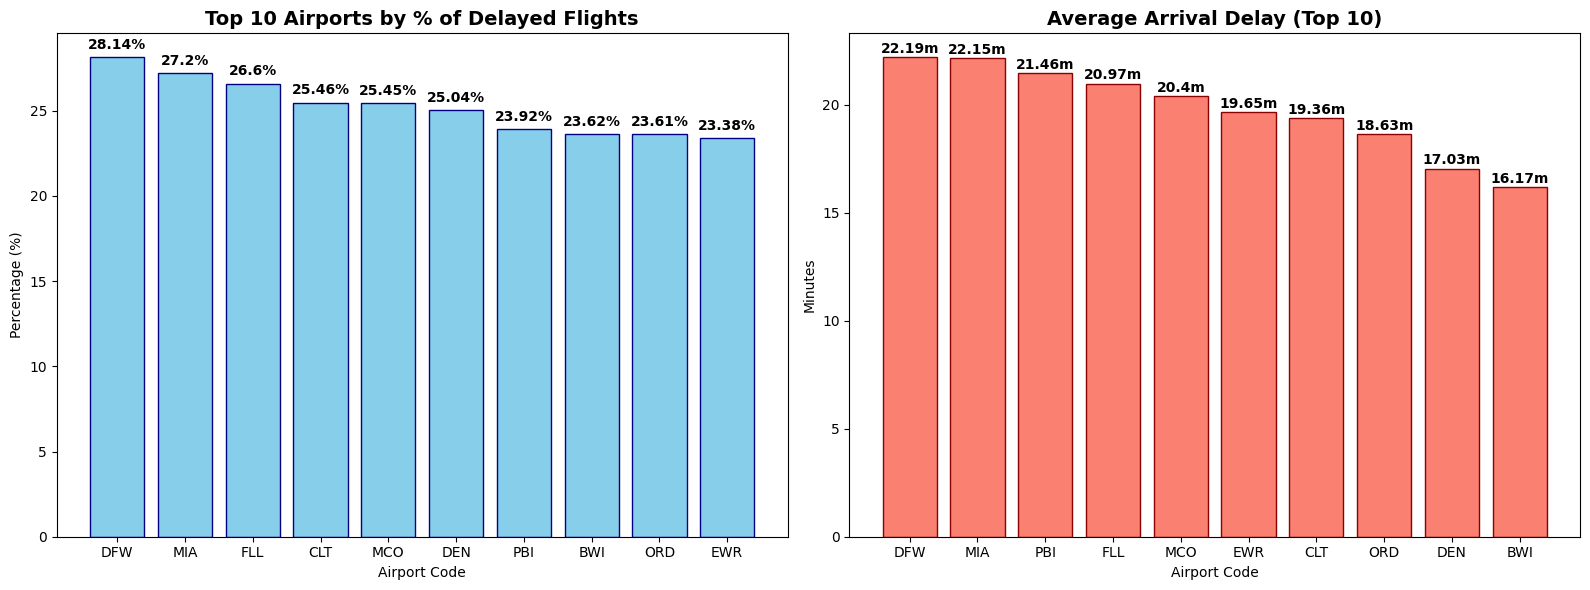

In [7]:
# 1. Fetch the data
df_delays = con.execute("""
    SELECT 
        ORIGIN, 
        COUNT(*) as total_flights,
        ROUND(AVG(ARR_DELAY_NEW), 2) as avg_arr_delay,
        ROUND(SUM(ARRIVAL_DELAYED) * 100.0 / COUNT(*), 2) as pct_delayed
    FROM flights_cleaned
    GROUP BY ORIGIN
    HAVING total_flights > 100
    ORDER BY pct_delayed DESC
    LIMIT 10
""").df()

# 2. Create the visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Percentage of Flights Delayed
ax1.bar(df_delays['ORIGIN'], df_delays['pct_delayed'], color='skyblue', edgecolor='navy')
ax1.set_title('Top 10 Airports by % of Delayed Flights', fontsize=14, fontweight='bold')
ax1.set_ylabel('Percentage (%)')
ax1.set_xlabel('Airport Code')
for i, v in enumerate(df_delays['pct_delayed']):
    ax1.text(i, v + 0.5, f"{v}%", ha='center', fontweight='bold')

# Plot 2: Average Arrival Delay (in minutes)
# We sort this one specifically by avg_arr_delay for clarity
df_avg_sorted = df_delays.sort_values('avg_arr_delay', ascending=False)
ax2.bar(df_avg_sorted['ORIGIN'], df_avg_sorted['avg_arr_delay'], color='salmon', edgecolor='darkred')
ax2.set_title('Average Arrival Delay (Top 10)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Minutes')
ax2.set_xlabel('Airport Code')
for i, v in enumerate(df_avg_sorted['avg_arr_delay']):
    ax2.text(i, v + 0.2, f"{v}m", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### EDA #3: Airports Worst Affected by Weather Delays

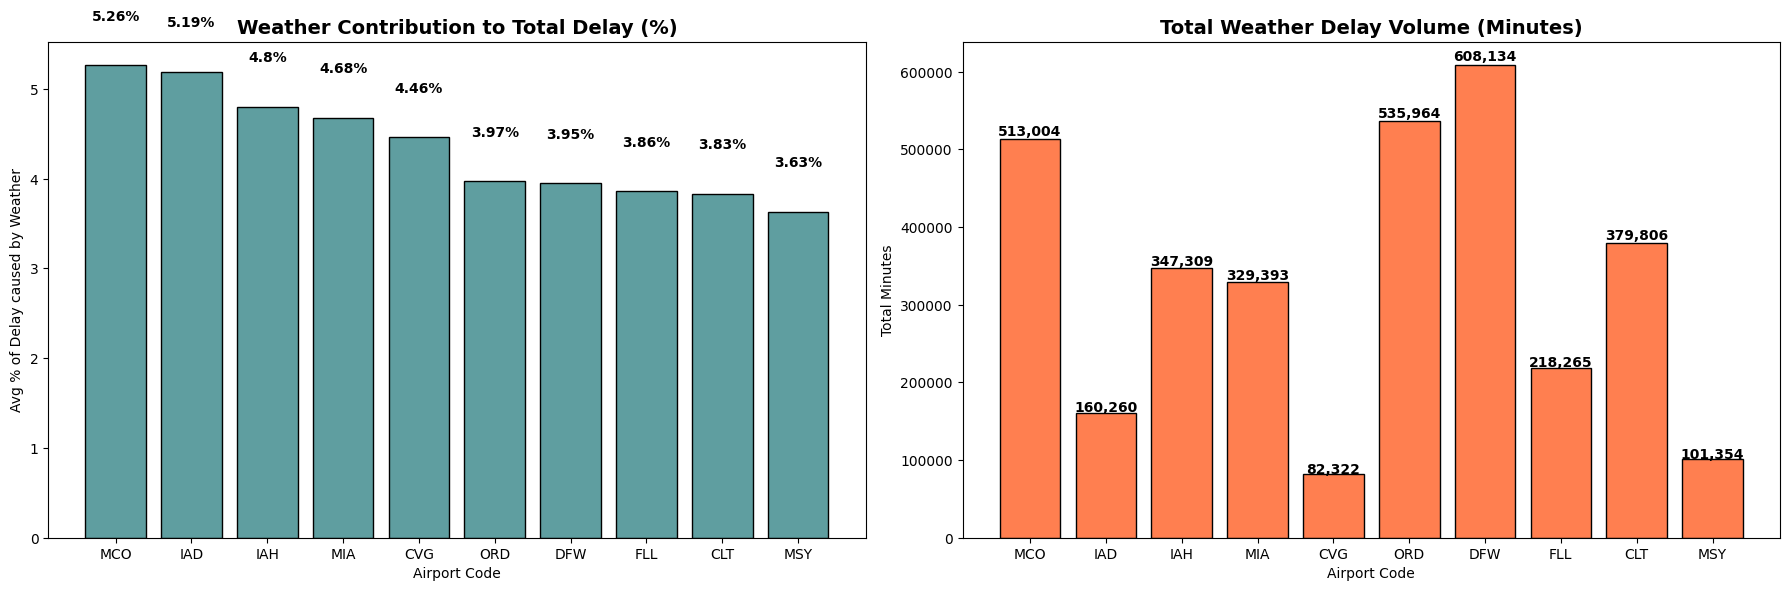

In [8]:
# 1. Fetch the data from the query
df_weather = con.execute("""
    SELECT 
        ORIGIN,
        ROUND(AVG(WEATHER_DELAY_FRACTION) * 100, 2) as avg_weather_contribution_pct,
        ROUND(SUM(WEATHER_DELAY), 0) as total_weather_delay_minutes
    FROM flights_cleaned
    WHERE ARRIVAL_DELAYED = 1
    GROUP BY ORIGIN
    ORDER BY avg_weather_contribution_pct DESC
    LIMIT 10
""").df()

# 2. Create the visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1: Weather Contribution Percentage
# This shows which airports' delays are most "caused" by weather
ax1.bar(df_weather['ORIGIN'], df_weather['avg_weather_contribution_pct'], color='cadetblue', edgecolor='black')
ax1.set_title('Weather Contribution to Total Delay (%)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Avg % of Delay caused by Weather')
ax1.set_xlabel('Airport Code')

# Add percentage labels on top of bars
for i, v in enumerate(df_weather['avg_weather_contribution_pct']):
    ax1.text(i, v + 0.5, f"{v}%", ha='center', fontweight='bold')

# Plot 2: Total Weather Delay Minutes
# This shows the sheer volume of weather delays at these same airports
ax2.bar(df_weather['ORIGIN'], df_weather['total_weather_delay_minutes'], color='coral', edgecolor='black')
ax2.set_title('Total Weather Delay Volume (Minutes)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Total Minutes')
ax2.set_xlabel('Airport Code')

# Add volume labels (formatted with commas)
for i, v in enumerate(df_weather['total_weather_delay_minutes']):
    ax2.text(i, v + (v * 0.01), f"{int(v):,}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### EDA #4: Making sure each airport has flight logs for each day

In [9]:
completeness_query = """
WITH date_range AS (
    -- 1. Get the dataset boundaries
    SELECT 
        MIN(CAST(DATE AS DATE)) as start_date, 
        MAX(CAST(DATE AS DATE)) as end_date 
    FROM flights_cleaned
),
all_dates AS (
    -- 2. Unnest the series into rows, then cast to DATE
    SELECT 
        CAST(unnest(generate_series(start_date, end_date, interval '1 day')) AS DATE) as expected_date
    FROM date_range
),
airports AS (
    -- 3. Get the Top 50 list
    SELECT DISTINCT ORIGIN FROM flights_cleaned
),
grid AS (
    -- 4. Create the Master Schedule (50 Airports x Total Days)
    SELECT a.ORIGIN, d.expected_date
    FROM airports a, all_dates d
),
daily_activity AS (
    -- 5. Collapse flight data to one row per airport per day
    SELECT 
        ORIGIN, 
        CAST(DATE AS DATE) as flight_date
    FROM flights_cleaned
    GROUP BY ORIGIN, flight_date
)
-- 6. Compare Grid to Activity
SELECT 
    g.ORIGIN,
    COUNT(g.expected_date) AS total_expected_days,
    COUNT(da.flight_date) AS days_with_data,
    (COUNT(g.expected_date) - COUNT(da.flight_date)) AS missing_days,
    ROUND((COUNT(da.flight_date)::FLOAT / COUNT(g.expected_date)) * 100, 2) AS completeness_score
FROM grid g
LEFT JOIN daily_activity da 
    ON g.ORIGIN = da.ORIGIN 
    AND g.expected_date = da.flight_date
GROUP BY g.ORIGIN
ORDER BY completeness_score ASC;
"""

df_completeness = con.execute(completeness_query).df()
display(df_completeness)

,ORIGIN,total_expected_days,days_with_data,missing_days,completeness_score
0,MCO,1096,1096,0,100.0
1,DAL,1096,1096,0,100.0
2,BNA,1096,1096,0,100.0
3,ORD,1096,1096,0,100.0
4,PIT,1096,1096,0,100.0
5,STL,1096,1096,0,100.0
6,PHX,1096,1096,0,100.0
7,SAT,1096,1096,0,100.0
8,BDL,1096,1096,0,100.0
9,BWI,1096,1096,0,100.0


In [10]:
con.close()